In [58]:
# !pip install -r ../requirements.txt

# CNN Spectrogram Classifier - Training and Q9.15 Golden Model

This notebook owns the CNN branch of the accelerator end to end: it builds
32x32x4 spectrograms from the quantised capture set, trains the float32
reference network, quantises it to Q9.15, writes the ROM images the RTL
loads, and re-runs inference bit-true in NumPy so the SystemVerilog testbench
has a golden result to compare against.

## 1. Where this sits in the hardware

`cnn_inference_path.sv` wires up path B of `top_system`:

```
[ UART sensor frame ]             4 vibration words per frame, Q9.15
          |
          v
[ fir_decimator_32_dualmode ]     /4 -> /4 -> /2, 47/67/83 taps, Q1.17 coeffs
   (DECIM_RATE = 32 only)         bypassed when DECIM_RATE = 1
          |
          v
[ lms_filter_time_serial ]        8-tap predictor; the framer is fed the ERROR
   (USE_LMS only)                 e(n) = x(n) - sum w_i x(n-i)
          |
          v
[ sample_buffer_64_hop_dualmode ] 64-sample frames, FFT_HOP = 64, no overlap
          |
          v
[ mean_remover_64_dualmode ]      removes the frame mean, Q9.15 -> Q10.15
          |
          v
[ hann_window_64_dualmode ]       Q1.17 window, back down to Q9.15
          |
          v
[ fft_shared_4sensor ]            64-point FFT, NORMALIZE = 1, so DFT/64
          |
          v
[ fft_to_stream_adapter x4 ]      keeps bins 0..31, emits |X[k]| by
                                  alpha-max-beta-min
          |
          v
[ spectrogram_generator x4 ]      32 frames x 32 bins per sensor
          |
          v
[ spectrogram_4ch_join ]          one 4-channel pixel per beat
          |
          v
[ cnn_top ]                       Conv2D(4->8, 3x3, pad 1) -> ReLU
                                  -> MaxPool 2x2 -> Flatten(2048) -> Dense(4)
```

The image axes follow that stream order: a **row is one time frame** and a
**column is one frequency bin**, which is why `cnn_inference_path.sv` passes
`IMG_WIDTH = SPEC_BINS` and `IMG_HEIGHT = SPEC_FRAMES`.

The four logits leave `cnn_top` in port order - `m_data_normal`,
`m_data_unbalance`, `m_data_misalign`, `m_data_bearing` - so this notebook
indexes the classes the same way. `inference_arbiter.sv` re-maps them onto the
MLP's own numbering when it forms the system verdict; that translation lives
in the RTL and must not be duplicated here.

## 2. Q9.15 arithmetic

Every sample, coefficient and logit on this path is a 24-bit signed
fixed-point number with 15 fractional bits, matching
`system_types_pkg::DATA_WIDTH` and `mlp_weights_pkg::Q_FRAC`.

| property | value |
| --- | --- |
| word length | 24 bits, two's complement |
| fractional bits | 15 |
| scale | 2^15 = 32768 |
| integer codes | -8388608 .. 8388607 |
| real values | -256.0 .. 255.999969482421875 |
| resolution | 2^-15 ~= 3.0518e-05 |

Quantisation is `q = clip(round(x * 32768), -2^23, 2^23 - 1)`, the same rule
`Scripts/process_dataset/quantize.py` applied to the captures.

`mac_q8_16.sv` accumulates full 48-bit products and shifts only at the end:
`y = saturate24(sum(a_i * b_i) >> 15)`, an arithmetic shift with no rounding,
over an accumulator that wraps at 48 bits. Section 8 reproduces that exactly,
wrap included.

## 3. Three things to know before trusting the exports

**The build options here must match `system_types_pkg`.** `USE_LMS`,
`DECIM_RATE` and `FFT_HOP` live in that package (`FRONT_END_NOTE`) and reach
the fabric through `top_system.sv`. The switches in the next cell mirror them.
Train against a front end the hardware does not have and the exported weights
are fitted to features the fabric never produces.

**The CNN RTL is still Q8.16.** `mac_q8_16.sv:5`, `cnn_top.sv:14`,
`conv2d_fsm.sv:5` and `dense_layer_fsm.sv:5` all default `FRAC_BITS` to 16,
and the four CNN testbenches override it to 16 as well. Until those become 15
the ROMs written here are read one binary place off. The module name
`mac_q8_16` is a leftover from the same change.

**The dense layer flattens in hardware order, not PyTorch order.**
`dense_layer_fsm.sv:143-152` advances `rom_addr` once per (pixel, channel)
pair while `ch` walks the 8 pooled channels inside each pixel, so the feature
index is `f = (row * 16 + col) * 8 + channel` - pixel-major, channel-minor.
`nn.Flatten` would give `f = channel * 256 + row * 16 + col`. The model below
permutes to `(N, H, W, C)` before flattening so the learned weights land in
the order the ROM reader expects. An archive produced without that permute
addresses the pooled feature map through a scrambled index.

In [ ]:
# ============================================================================
# Imports, reproducibility and global configuration
# ============================================================================
from __future__ import annotations

import copy
import re
from dataclasses import dataclass
from pathlib import Path

import numpy as np
from numpy.lib.stride_tricks import sliding_window_view

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Subset

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


def locate_project_root(start: Path) -> Path:
    """Walks up from `start` until both RTL/ and Scripts/ are siblings."""
    for candidate in (start, *start.parents):
        if (candidate / "RTL").is_dir() and (candidate / "Scripts").is_dir():
            return candidate
    raise RuntimeError(f"Could not locate the repository root starting at {start}")


PROJECT_ROOT = locate_project_root(Path.cwd().resolve())
NOTEBOOK_DIR = PROJECT_ROOT / "Scripts" / "cnn"

# Q9.15 captures written by Scripts/process_dataset/quantize.py.
DATASET_DIR = PROJECT_ROOT / "Scripts" / "process_dataset" / "dataset_q915" / "vibration"

# The RTL's own coefficient ROMs, reused so the Python front end filters with
# exactly the numbers the hardware filters with.
COEFF_DIR = (PROJECT_ROOT / "RTL" / "FFT"
             / "model_sim_four_modes_quartus_shared_fft" / "coefficients")

CACHE_DIR = NOTEBOOK_DIR / "cache"

# Where the ROM images land. Scripts/cnn/rtl is gitignored scratch space;
# RTL/mem/cnn is the tracked copy Quartus and top_system.sv actually read, so
# promoting a model means copying the four files across. Uncomment the second
# entry to write both in one go.
EXPORT_DIRS = [
    NOTEBOOK_DIR / "rtl",
    # PROJECT_ROOT / "RTL" / "mem" / "cnn",
]

# tb_cnn_top.sv reads this file as ../Scripts/cnn/cnn_tb_input.mem.
TB_INPUT_FILE = NOTEBOOK_DIR / "cnn_tb_input.mem"
MODEL_STATE_FILE = NOTEBOOK_DIR / "cnn_model.pth"
MODEL_Q915_FILE = NOTEBOOK_DIR / "cnn_model_q915.npz"

for directory in (CACHE_DIR, *EXPORT_DIRS):
    directory.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Class order == cnn_top port order. See section 1.
CLASS_NAMES = ["Normal", "Unbalance", "Misalign", "Bearing"]
NUM_CLASSES = len(CLASS_NAMES)

# ---- front-end build options -----------------------------------------------
# Mirror of system_types_pkg (FRONT_END_NOTE). Change these together with the
# package, never on their own.
USE_LMS = True            # system_types_pkg::USE_LMS
USE_DECIMATOR = True     # system_types_pkg::DECIM_RATE == 32
LMS_MU_SHIFT = 16         # dsp_preprocessing_subsystem parameter
HOP_SIZE = 64             # system_types_pkg::FFT_HOP

# fft_to_stream_adapter.sv emits |X[k]| through alpha-max-beta-min. "real"
# reproduces what it forwarded before - Re(X[k]) - and section 7 measures why
# that was the wrong feature. "exact" uses a true hypot, which no hardware
# computes and which exists only to show what the approximation costs.
SPECTROGRAM_SOURCE = "magnitude"

# Training-only knob with no hardware counterpart. The RTL emits one continuous
# stream of spectrogram rows and cnn_top consumes 32 at a time; nothing stops
# the host from cutting that same stream into OVERLAPPING 32-row images when
# building a training set. ROW_HOP = 32 reproduces the fabric's own disjoint
# framing; smaller values are pure augmentation. See section 9.
ROW_HOP = 8

# ---- the switches above must match the fabric --------------------------------
def rtl_front_end_options(package: Path | None = None) -> dict[str, int]:
    """Reads USE_LMS / DECIM_RATE / FFT_HOP out of system_types_pkg.sv."""
    path = package or (PROJECT_ROOT / "RTL" / "top_system" / "rtl" / "system_types_pkg.sv")
    text = path.read_text()
    found: dict[str, int] = {}
    for name in ("USE_LMS", "DECIM_RATE", "FFT_HOP"):
        match = re.search(rf"localparam\s+(?:bit|int)\s+{name}\s*=\s*(?:1'b)?(\d+)\s*;", text)
        if match is None:
            raise RuntimeError(f"{path.name}: could not find localparam {name}")
        found[name] = int(match.group(1))
    return found


def check_matches_rtl() -> None:
    """Fails loudly when the notebook and the RTL disagree about the front end.

    Training against a front end the fabric does not have produces weights
    fitted to features it never emits. The failure is silent in every other
    way, so it is worth an exception here.
    """
    rtl = rtl_front_end_options()
    wanted = {
        "USE_LMS": int(USE_LMS),
        "DECIM_RATE": 32 if USE_DECIMATOR else 1,
        "FFT_HOP": HOP_SIZE,
    }
    bad = {k: (v, rtl[k]) for k, v in wanted.items() if v != rtl[k]}
    if bad:
        lines = "\n".join(f"    {k}: notebook {n}, system_types_pkg {r}"
                           for k, (n, r) in bad.items())
        raise RuntimeError(
            "Front-end mismatch between this notebook and the RTL:\n" + lines +
            "\n  Change one side to match the other before training. The RTL side "
            "lives in\n  RTL/top_system/rtl/system_types_pkg.sv (FRONT_END_NOTE).")
    print(f"[CONFIG] RTL front end     : matches system_types_pkg {rtl}")


print(f"[CONFIG] Project root      : {PROJECT_ROOT}")
print(f"[CONFIG] Capture set       : {DATASET_DIR}")
print(f"[CONFIG] Torch device      : {DEVICE}")
print(f"[CONFIG] Classes           : {CLASS_NAMES}")
print(f"[CONFIG] Decimator / LMS   : {USE_DECIMATOR} / {USE_LMS} (mu = 2^-{LMS_MU_SHIFT})")
print(f"[CONFIG] Frame hop / row hop: {HOP_SIZE} / {ROW_HOP}")
print(f"[CONFIG] Spectrogram source: {SPECTROGRAM_SOURCE}")
check_matches_rtl()

### 4. Q9.15 primitives

Four helpers carry the fixed-point contract through the rest of the notebook.
`round_shift` is the one worth reading: the RTL rounds half **away from
zero**, not half to even and not half up, and it gets there by negating first
(`round_and_saturate` in `fir_decimator_stage_dualmode.v:200-256`,
`rounded_divide_64` in `mean_remover_64_dualmode.v:142-170`). Rounding a
negative sample the other way puts a one-LSB error on roughly half the
stream, which is exactly the drift that makes a golden model worthless.

In [60]:
# ============================================================================
# Q9.15 fixed-point primitives
# ============================================================================
TOTAL_BITS = 24
FRAC_BITS = 15
SCALE = 1 << FRAC_BITS                        # 32768
Q915_MIN = -(1 << (TOTAL_BITS - 1))           # -8388608
Q915_MAX = (1 << (TOTAL_BITS - 1)) - 1        #  8388607
HEX_DIGITS = TOTAL_BITS // 4                  # 6

# Geometry and widths taken from the RTL.
COEFF_WIDTH = 18              # Q1.17 FIR and Hann coefficients
COEFF_FRAC_BITS = 17
FRAME_SIZE = 64               # sample_buffer_64_hop_dualmode
HOP_SIZE = 64                 # dsp_preprocessing_subsystem default: no overlap
FFT_SIZE = 64                 # fft_64_dualmode
SPEC_BINS = 32                # system_types_pkg::SPEC_BINS   -> image width
SPEC_FRAMES = 32              # system_types_pkg::SPEC_FRAMES -> image height
N_VIB = 4                     # system_types_pkg::N_VIB
CONV_CHANNELS = 8             # cnn_top parameter CHANNELS
POOL_SIZE = 2                 # maxpool_2x2
ACC_BITS = 2 * TOTAL_BITS     # mac_q8_16.sv accumulator width

POOLED_HEIGHT = SPEC_FRAMES // POOL_SIZE      # 16
POOLED_WIDTH = SPEC_BINS // POOL_SIZE         # 16
IN_FEATURES = POOLED_HEIGHT * POOLED_WIDTH * CONV_CHANNELS   # 2048


def saturate(value, bits: int = TOTAL_BITS):
    """Clamps to a signed `bits`-wide range, the way the RTL saturates."""
    limit = 1 << (bits - 1)
    return np.clip(np.asarray(value, dtype=np.int64), -limit, limit - 1)


def wrap_signed(value, bits: int):
    """Two's complement wraparound, as a fixed-width accumulator does."""
    span = 1 << bits
    half = span >> 1
    return ((np.asarray(value, dtype=np.int64) + half) % span) - half


def round_shift(value, shift: int):
    """Arithmetic right shift with round-half-away-from-zero."""
    value = np.asarray(value, dtype=np.int64)
    rounding = np.int64(1) << (shift - 1)
    magnitude = (np.abs(value) + rounding) >> shift
    return np.where(value < 0, -magnitude, magnitude)


def round_half_away(value):
    """The same rounding rule applied to a real-valued array."""
    value = np.asarray(value, dtype=np.float64)
    return np.trunc(value + np.copysign(0.5, value)).astype(np.int64)


def float_to_q915(value):
    """Quantises real values to Q9.15 integer codes."""
    scaled = np.rint(np.asarray(value, dtype=np.float64) * SCALE)
    return saturate(scaled).astype(np.int64)


def q915_to_float(value):
    """Interprets Q9.15 integer codes as real values."""
    return np.asarray(value, dtype=np.float64) / SCALE


print(f"[Q9.15] range : [{Q915_MIN}, {Q915_MAX}] "
      f"-> [{q915_to_float(Q915_MIN):.6f}, {q915_to_float(Q915_MAX):.6f}]")
print(f"[Q9.15] step  : {1.0 / SCALE:.10f}")
print(f"[Q9.15] image : {SPEC_FRAMES} frames x {SPEC_BINS} bins x {N_VIB} sensors")
print(f"[Q9.15] dense : {IN_FEATURES} features -> {NUM_CLASSES} logits")

[Q9.15] range : [-8388608, 8388607] -> [-256.000000, 255.999969]
[Q9.15] step  : 0.0000305176
[Q9.15] image : 32 frames x 32 bins x 4 sensors
[Q9.15] dense : 2048 features -> 4 logits


### 5. Reading the quantised captures

The captures are already Q9.15, so nothing is re-quantised here - the files
are read as integer codes and stay integers all the way to the FFT.

`quantize.py` writes one code per line as six uppercase hex digits followed by
a Unix newline, so every record is exactly seven bytes. That fixed stride is
what makes the reader fast enough to be usable: a single `np.fromfile` pulls
the bytes in and the hex conversion is vectorised. Parsing a 7.68-million-line
capture a line at a time takes minutes; this takes well under a second.

In [61]:
# ============================================================================
# Capture reader and case discovery
# ============================================================================
MEM_LINE_BYTES = HEX_DIGITS + 1               # six hex digits plus a newline
_HEX_WEIGHTS = 1 << (4 * np.arange(HEX_DIGITS - 1, -1, -1, dtype=np.int64))
_SIGN_BIT = 1 << (TOTAL_BITS - 1)


def read_mem_file(path: Path, max_samples: int | None = None) -> np.ndarray:
    """Loads a .mem capture and returns sign-extended Q9.15 integer codes."""
    count = -1 if max_samples is None else MEM_LINE_BYTES * max_samples
    raw = np.fromfile(path, dtype=np.uint8, count=count)

    usable = (raw.size // MEM_LINE_BYTES) * MEM_LINE_BYTES
    lines = raw[:usable].reshape(-1, MEM_LINE_BYTES)
    if lines.size and not np.all(lines[:, -1] == 0x0A):
        raise ValueError(f"{path}: expected {MEM_LINE_BYTES}-byte records ending in LF")

    digits = lines[:, :HEX_DIGITS].astype(np.int64)
    # '0'-'9' sit at 0x30..0x39; clearing bit 5 folds 'a'-'f' onto 'A'-'F'.
    digits = np.where(digits <= 0x39, digits - 0x30, (digits & ~0x20) - 0x37)
    codes = digits @ _HEX_WEIGHTS
    return np.where(codes >= _SIGN_BIT, codes - (1 << TOTAL_BITS), codes)


# Case directories are named <torque>_<condition>[_<severity>]. Bearing faults
# appear as BPFI/BPFO, and the 2Nm captures carry an "Unbalalnce" typo that the
# truncated pattern below tolerates on purpose.
LABEL_PATTERNS = (
    (re.compile(r"normal", re.IGNORECASE), 0),
    (re.compile(r"unbala", re.IGNORECASE), 1),
    (re.compile(r"misalign", re.IGNORECASE), 2),
    (re.compile(r"bpf[io]|bearing", re.IGNORECASE), 3),
)


def label_for_case(case_name: str) -> int | None:
    for pattern, label in LABEL_PATTERNS:
        if pattern.search(case_name):
            return label
    return None


@dataclass(frozen=True)
class CaptureCase:
    name: str
    label: int
    sensor_files: tuple[Path, ...]


def discover_cases(dataset_dir: Path = DATASET_DIR) -> list[CaptureCase]:
    """Collects every case directory that holds all four vibration sensors."""
    if not dataset_dir.is_dir():
        raise RuntimeError(f"Capture set not found: {dataset_dir}")

    cases: list[CaptureCase] = []
    for directory in sorted(path for path in dataset_dir.iterdir() if path.is_dir()):
        label = label_for_case(directory.name)
        if label is None:
            print(f"[DATASET] Skipping {directory.name}: no class matches the name")
            continue

        files = tuple(directory / f"{directory.name}_sensor{index}.mem"
                      for index in range(1, N_VIB + 1))
        missing = [path.name for path in files if not path.is_file()]
        if missing:
            print(f"[DATASET] Skipping {directory.name}: missing {missing}")
            continue

        cases.append(CaptureCase(directory.name, label, files))

    if not cases:
        raise RuntimeError(f"No usable case directories under {dataset_dir}")
    return cases

In [62]:
CASES = discover_cases()

print(f"[DATASET] {len(CASES)} cases under {DATASET_DIR.name}/")
for label, name in enumerate(CLASS_NAMES):
    members = [case.name for case in CASES if case.label == label]
    preview = ", ".join(members[:3]) + (", ..." if len(members) > 3 else "")
    print(f"  {label} {name:<10s} {len(members):2d} cases  {preview}")

_probe = read_mem_file(CASES[0].sensor_files[0], max_samples=200_000)
print(f"\n[DATASET] Probe {CASES[0].sensor_files[0].name}: {_probe.size} samples, "
      f"codes [{_probe.min()}, {_probe.max()}] "
      f"-> [{q915_to_float(_probe.min()):.4f}, {q915_to_float(_probe.max()):.4f}] g")

[DATASET] 45 cases under vibration/
  0 Normal      3 cases  0Nm_Normal, 2Nm_Normal, 4Nm_Normal
  1 Unbalance  15 cases  0Nm_Unbalance_0583mg, 0Nm_Unbalance_1169mg, 0Nm_Unbalance_1751mg, ...
  2 Misalign    9 cases  0Nm_Misalign_01, 0Nm_Misalign_03, 0Nm_Misalign_05, ...
  3 Bearing    18 cases  0Nm_BPFI_03, 0Nm_BPFI_10, 0Nm_BPFI_30, ...

[DATASET] Probe 0Nm_BPFI_03_sensor1.mem: 200000 samples, codes [-2337661, 2267553] -> [-71.3398, 69.2002] g


### 6. The front end, part 1: the /32 FIR decimator

> **Off by default.** `DECIM_RATE = 1` in `system_types_pkg`, so the shipped
> build bypasses this filter and the FFT sees the raw 25.6 kHz stream. The
> module is still modelled here because the bypass is a build option and the
> comparison in section 9 needs both sides of it.

`fir_decimator_32_dualmode.v` cascades three decimating FIR stages,
25.6 kHz -> 6.4 kHz -> 1.6 kHz -> 800 Hz. Each stage keeps a `NUM_TAPS`-deep
history that starts zeroed, multiplies by Q1.17 coefficients into a 64-bit
accumulator, and emits one output on every `DECIMATION`-th input - rounded
half away from zero and saturated back to Q9.15.

The point of decimating is resolution. A 64-point FFT at the raw 25.6 kHz
rate gives 400 Hz per bin, which buries the whole diagnostic band in bins 0
and 1. Dropping the rate first is what makes a 64-point transform useful.

Three details are worth stating because they are easy to get wrong:

* **Output phase.** The stage's decimation counter fires on the *last* input
  of each group of `DECIMATION`, and that input is tap 0. So output `m` is
  `sum(h[k] * x[(m + 1) * D - 1 - k])`, not `sum(h[k] * x[m * D - k])`.
* **Zero history.** Taps beyond `active_valid_count` read as zero, so the
  stream starts against a zero-padded history rather than settling.
* **Why float64 is still bit-exact.** A 24-bit sample times an 18-bit
  coefficient is at most 2^41, and 83 of those sum to under 2^48 - well
  inside float64's 53-bit mantissa. Every intermediate is represented
  exactly, so the MACs can run through BLAS without giving anything up.

**Sample rate caveat.** This decimator lands on 800 Hz, so a 64-point FFT
resolves 12.5 Hz per bin. `fft_peak_mdc.sv:9` and
`fft_to_mlp_collector.sv:121` both assume 6.25 Hz per bin, which needs a /64
decimation to 400 Hz. The CNN is trained here against whatever the RTL
actually produces, so it stays self-consistent either way, but the two
statements in the RTL cannot both be true.

In [63]:
# ============================================================================
# Front end, part 1: fir_decimator_32_dualmode
# ============================================================================
FIR_STAGES = (
    ("stage1_decim4_q117.bin", 47, 4),
    ("stage2_decim4_q117.bin", 67, 4),
    ("stage3_decim2_q117.bin", 83, 2),
)
DECIMATION_FACTOR = 4 * 4 * 2                 # 32


def load_coefficient_rom(path: Path, num_taps: int,
                         width: int = COEFF_WIDTH) -> np.ndarray:
    """Reads a $readmemb ROM image and sign-extends the coefficients.

    The .bin files hold one binary word per line and are padded out to the
    ROM depth, so only the first `num_taps` entries are meaningful.
    """
    words = path.read_text().split()
    if len(words) < num_taps:
        raise ValueError(f"{path}: holds {len(words)} words, needs {num_taps}")

    codes = np.array([int(word, 2) for word in words[:num_taps]], dtype=np.int64)
    sign_bit = 1 << (width - 1)
    return np.where(codes >= sign_bit, codes - (1 << width), codes)


def decimate_stage(samples: np.ndarray, coefficients: np.ndarray,
                   decimation: int, chunk: int = 1 << 16) -> np.ndarray:
    """Runs one decimating FIR stage over a Q9.15 stream."""
    num_taps = coefficients.size
    num_outputs = samples.size // decimation
    if num_outputs == 0:
        return np.zeros(0, dtype=np.int64)

    # Prepending NUM_TAPS-1 zeros reproduces the RTL's empty history, and
    # makes window row j cover x[j - NUM_TAPS + 1 .. j].
    padded = np.concatenate((np.zeros(num_taps - 1, dtype=np.float64),
                             samples.astype(np.float64)))
    windows = sliding_window_view(padded, num_taps)[decimation - 1::decimation]
    taps = coefficients[::-1].astype(np.float64)

    accumulator = np.empty(num_outputs, dtype=np.int64)
    for start in range(0, num_outputs, chunk):
        stop = min(start + chunk, num_outputs)
        accumulator[start:stop] = np.rint(windows[start:stop] @ taps)

    return saturate(round_shift(accumulator, COEFF_FRAC_BITS))


class FirDecimator32:
    """Python model of fir_decimator_32_dualmode.v."""

    def __init__(self, coefficient_dir: Path | None = None):
        directory = coefficient_dir or (COEFF_DIR / "fir")
        self.stages = [
            (load_coefficient_rom(directory / filename, num_taps), decimation)
            for filename, num_taps, decimation in FIR_STAGES
        ]

    def __call__(self, samples: np.ndarray) -> np.ndarray:
        for coefficients, decimation in self.stages:
            samples = decimate_stage(samples, coefficients, decimation)
        return samples


_decimator_probe = FirDecimator32()
for (filename, num_taps, decimation), (coefficients, _) in zip(FIR_STAGES,
                                                               _decimator_probe.stages):
    gain = coefficients.sum() / (1 << COEFF_FRAC_BITS)
    print(f"[FIR] {filename:<24s} {num_taps:2d} taps  /{decimation}  "
          f"DC gain {gain:.6f}  coeff range [{coefficients.min()}, {coefficients.max()}]")

[FIR] stage1_decim4_q117.bin   47 taps  /4  DC gain 1.000000  coeff range [-1844, 17924]
[FIR] stage2_decim4_q117.bin   67 taps  /4  DC gain 1.000000  coeff range [-3872, 22528]
[FIR] stage3_decim2_q117.bin   83 taps  /2  DC gain 1.000000  coeff range [-11338, 57346]


### 7. The front end, part 2: LMS, framing and magnitude

#### The LMS

`lms_filter_time_serial.v` predicts `x(n)` from the eight samples before it and
hands the framer the **error**, not the prediction. So the FFT sees the part
the predictor could not explain - a whitening filter. Broadband content
survives; narrowband tonal content is attenuated. Worth holding onto, because
the 1x and 2x shaft tones that identify unbalance and misalignment *are* the
tonal part.

**The step size is amplitude-tuned, and the amplitude depends on the
decimator.** The update is `(e * x) >>> (2*15 + LMS_MU_SHIFT - 20)`, which at
the default `LMS_MU_SHIFT = 16` is a shift of 26. Whether that does anything
depends entirely on how big `e * x` is - and the FIR decimator is a lowpass, so
it drops the signal's standard deviation by roughly 28x and `|e*x|` by about
2^10:

| capture | domain | std (codes) | log2 \|e·x\| | residual / input |
| --- | --- | --- | --- | --- |
| 0Nm_Normal | raw 25.6 kHz | 32,112 | 29.9 | 0.874 |
| 0Nm_Normal | decimated | 1,132 | 20.3 | 0.996 |
| 0Nm_Unbalance_3318mg | raw 25.6 kHz | 33,480 | 30.1 | 0.853 |
| 0Nm_Unbalance_3318mg | decimated | 1,242 | 20.6 | 0.997 |
| 0Nm_BPFI_30 | raw 25.6 kHz | 237,786 | 35.7 | 0.693 |
| 0Nm_BPFI_30 | decimated | 6,547 | 25.4 | 0.992 |
| 0Nm_Misalign_05 | raw 25.6 kHz | 87,711 | 32.8 | 0.795 |
| 0Nm_Misalign_05 | decimated | 3,314 | 23.4 | 0.992 |

So `LMS_MU_SHIFT = 16` is matched to the **bypass** path, where it removes
13-31 % of the energy and is genuinely adapting. Put the decimator in front of
it and every update truncates to zero: the residual is 99 %+ of the input and
the spectrum comes out bit-identical. The equivalent step for the decimated
path is around `LMS_MU_SHIFT = 6`, ten bits lower, which is exactly the gap the
table shows.

One detail to know if you ever run it in that starved regime: the update uses
an arithmetic (floor) shift, so a sub-LSB update rounds to 0 for a positive
product and to -1 for a negative one. The taps then ratchet downward instead of
sitting still - measured coefficients settle around -0.006 in Q4.20, all
negative. Every other shift in this front end rounds half away from zero.

Classification, magnitude spectrogram, `ROW_HOP = 8`, case-level split, three
seeds:

| front end | images | accuracy | Normal | Unbalance | Misalign | Bearing |
| --- | --- | --- | --- | --- | --- | --- |
| decimator, no LMS | 6,509 | **87.7 ±0.2** | 96.6 | 100 | 50.0 | 100 |
| decimator, LMS 2^-16 | 6,509 | 87.5 ±0.4 | 95.3 | 99.7 | 50.0 | 100 |
| decimator, LMS 2^-6 | 6,509 | 78.6 ±1.1 | 36.4 | 95.1 | 50.0 | 100 |
| bypass, no LMS | 9,597 | 52.7 ±1.0 | 0.0 | 77.5 | 54.8 | 100 |
| **bypass, LMS 2^-16** | 9,597 | **75.0 ±0.6** | 60.3 | 93.6 | 50.0 | 100 |
| bypass, LMS 2^-12 | 9,597 | 56.5 ±0.4 | 8.0 | 86.3 | 50.2 | 100 |

Read across the two halves and the pattern is consistent: **mild whitening
helps, aggressive whitening hurts.** In the bypass build the LMS is doing real
work - it is worth 22 points and is the difference between recognising a
healthy machine and never predicting Normal at all. With the decimator in it is
a no-op at the shipped step, and turning the step up costs 9 points, because
what it starts removing is the tonal content two of the four classes are made
of.

#### Framing

With `FFT_HOP = 64` the frames do not overlap
(`sample_buffer_64_hop8_dualmode.v:5`), so framing is a strided window. Then
`mean_remover_64_dualmode` (rounded divide by 64, one guard bit, Q9.15 ->
Q10.15) and `hann_window_64_dualmode` (Q1.17 coefficients, rounded and
saturated back to Q9.15).

One approximation, stated plainly: `fft_64_dualmode` with `NORMALIZE = 1`
halves and rounds once per butterfly stage, six times over, delivering
`DFT/64`. The model divides by 64 once and rounds once. Everything upstream of
the FFT is bit-exact; the spectrogram itself can differ by an LSB or two.

#### Magnitude, not the real part

`fft_to_stream_adapter.sv` used to forward `Re(X[k])`. That is the wrong
feature, and it is measurable. Define the frame-to-frame coherence of the real
part as `|mean(Re(X_k))| / mean(|Re(X_k)|)` - near 1 if the sign is stable,
near 0 if it is not:

| capture | coherence |
| --- | --- |
| 0Nm_Unbalance_3318mg | 0.040 |
| 0Nm_Normal | 0.031 |
| 0Nm_Misalign_05 | 0.019 |
| 0Nm_BPFI_30 | 0.006 |

The 64-sample frame boundary is not phase-locked to the shaft, so `Re(X[k])`
flips sign essentially at random between rows and averages to nothing. The CNN
was being handed a sign-randomised spectrum. Magnitude is phase-invariant.
Measured over three seeds at 6,509 images, magnitude scores 87.7 % ±0.2 against
83.2 % ±4.3 for the real part - and note which one is reproducible.

The adapter computes alpha-max-beta-min, `max + (min>>1) - (min>>3)`, the same
approximation `fft_peak_mdc.sv:71-90` and `fft_to_mlp_collector` already use.
It costs no multiplier, runs −2.8 % to +6.8 % against a true hypot, and cannot
saturate here: that needs `|z|` above 186.2 in Q9.15 units and these
spectrograms live near 0.02. `bin_magnitude` below reproduces it exactly.

In [64]:
# ============================================================================
# Front end, part 2: the 8-tap time-domain LMS
# ============================================================================
# Bit-true model of lms_filter_time_serial.v. The filter predicts x(n) from the
# eight samples before it and the framer downstream is handed the ERROR, so
# what reaches the FFT is the part the predictor could not explain. That is a
# whitening filter: broadband content survives, narrowband tonal content is
# attenuated.
#
# Fixed-point contract, straight off the module's parameters:
#   samples      Q9.15, 24 bits
#   coefficients Q4.20, 24 bits
#   prediction   (sum w_i * x(n-i)) >>> 20, saturated to 24 bits
#   update       w_i += (e * x(n-i)) >>> UPDATE_SHIFT, saturated
#   UPDATE_SHIFT = 2*15 + LMS_MU_SHIFT - 20
#
# Both shifts are ARITHMETIC (floor), not round-half-away-from-zero like every
# other shift in this front end. That asymmetry matters at small step sizes --
# see the note in section 7.
LMS_TAPS = 8
LMS_COEFF_FRAC_BITS = 20


def lms_update_shift(mu_shift: int = LMS_MU_SHIFT) -> int:
    """UPDATE_SHIFT as lms_filter_time_serial.v computes it."""
    return 2 * FRAC_BITS + mu_shift - LMS_COEFF_FRAC_BITS


def lms_error(samples: np.ndarray, mu_shift: int = LMS_MU_SHIFT,
              adapt: bool = True) -> np.ndarray:
    """Q9.15 stream -> the LMS prediction residual, bit-true.

    Unrolled into locals on purpose: the loop is inherently sequential and this
    shape runs about three times faster than the same arithmetic over arrays.
    """
    shift = lms_update_shift(mu_shift)
    h0 = h1 = h2 = h3 = h4 = h5 = h6 = h7 = 0
    w0 = w1 = w2 = w3 = w4 = w5 = w6 = w7 = 0
    residual = np.empty(samples.size, dtype=np.int64)

    for index, desired in enumerate(samples.tolist()):
        accumulator = (w0 * h0 + w1 * h1 + w2 * h2 + w3 * h3
                       + w4 * h4 + w5 * h5 + w6 * h6 + w7 * h7)
        estimate = accumulator >> LMS_COEFF_FRAC_BITS
        if estimate > Q915_MAX: estimate = Q915_MAX
        elif estimate < Q915_MIN: estimate = Q915_MIN

        error = desired - estimate
        if error > Q915_MAX: error = Q915_MAX
        elif error < Q915_MIN: error = Q915_MIN
        residual[index] = error

        if adapt:
            w0 = min(Q915_MAX, max(Q915_MIN, w0 + ((error * h0) >> shift)))
            w1 = min(Q915_MAX, max(Q915_MIN, w1 + ((error * h1) >> shift)))
            w2 = min(Q915_MAX, max(Q915_MIN, w2 + ((error * h2) >> shift)))
            w3 = min(Q915_MAX, max(Q915_MIN, w3 + ((error * h3) >> shift)))
            w4 = min(Q915_MAX, max(Q915_MIN, w4 + ((error * h4) >> shift)))
            w5 = min(Q915_MAX, max(Q915_MIN, w5 + ((error * h5) >> shift)))
            w6 = min(Q915_MAX, max(Q915_MIN, w6 + ((error * h6) >> shift)))
            w7 = min(Q915_MAX, max(Q915_MIN, w7 + ((error * h7) >> shift)))

        # The current sample becomes history only after prediction and update.
        h7 = h6; h6 = h5; h5 = h4; h4 = h3
        h3 = h2; h2 = h1; h1 = h0; h0 = desired

    return residual


print(f"[LMS] {LMS_TAPS} taps, mu = 2^-{LMS_MU_SHIFT}, "
      f"UPDATE_SHIFT = {lms_update_shift()}")

[LMS] 8 taps, mu = 2^-16, UPDATE_SHIFT = 26


In [65]:
# ============================================================================
# Front end, part 3: capture -> spectrogram rows
# ============================================================================
def bin_magnitude(bins: np.ndarray) -> np.ndarray:
    """alpha-max-beta-min, exactly as fft_to_stream_adapter.sv computes it.

    |z| ~= max(|re|,|im|) + (min>>1) - (min>>3), saturated to 2^23-1. The
    approximation runs -2.8% to +6.8% against a true hypot, and saturation
    cannot bite here: it needs |z| above 186.2 in Q9.15 units and these
    spectrograms live near 0.02.
    """
    real = saturate(np.abs(round_half_away(bins.real)))
    imag = saturate(np.abs(round_half_away(bins.imag)))
    larger = np.maximum(real, imag)
    smaller = np.minimum(real, imag)
    return np.minimum(larger + (smaller >> 1) - (smaller >> 3), Q915_MAX)


class SpectrogramFrontEnd:
    """One vibration channel of Q9.15 capture -> a stream of spectrogram rows.

    Mirrors preprocess_window_channel_lms.sv (or _no_lms) followed by the
    shared FFT and fft_to_stream_adapter.sv. A ROW is one 64-point FFT reduced
    to its first SPEC_BINS bins; SPEC_FRAMES consecutive rows make one CNN
    image, and section 9 decides how those rows are grouped.
    """

    def __init__(self, use_decimator: bool = USE_DECIMATOR,
                 use_lms: bool = USE_LMS,
                 mu_shift: int = LMS_MU_SHIFT,
                 source: str = SPECTROGRAM_SOURCE,
                 hop_size: int = HOP_SIZE):
        if source not in ("magnitude", "real", "exact"):
            raise ValueError(f"Unknown spectrogram source: {source!r}")
        if not 1 <= hop_size <= FRAME_SIZE:
            raise ValueError(f"hop_size must be 1..{FRAME_SIZE}, got {hop_size}")

        self.use_decimator = use_decimator
        self.use_lms = use_lms
        self.mu_shift = mu_shift
        self.source = source
        self.hop_size = hop_size

        self.decimator = FirDecimator32() if use_decimator else None
        self.hann = load_coefficient_rom(
            COEFF_DIR / "windowing" / "hann_64_q117.bin", FFT_SIZE)

    @property
    def decimation(self) -> int:
        return DECIMATION_FACTOR if self.use_decimator else 1

    def raw_samples_for_rows(self, rows: int) -> int:
        """Raw capture samples needed to produce `rows` spectrogram rows."""
        return (rows * self.hop_size + FRAME_SIZE) * self.decimation

    def rows(self, samples: np.ndarray) -> np.ndarray:
        """(n_samples,) Q9.15 -> (n_rows, SPEC_BINS) Q9.15."""
        if self.decimator is not None:
            samples = self.decimator(samples)
        if self.use_lms:
            samples = lms_error(samples, self.mu_shift)

        if samples.size < FRAME_SIZE:
            return np.zeros((0, SPEC_BINS), dtype=np.int64)

        # sample_buffer_64_hop_dualmode: first frame at 64 samples, then one
        # every hop_size. With hop_size = 64 the frames do not overlap.
        count = (samples.size - FRAME_SIZE) // self.hop_size + 1
        frames = sliding_window_view(samples.astype(np.int64),
                                     FRAME_SIZE)[::self.hop_size][:count]

        # mean_remover_64_dualmode: rounded divide by 64, one guard bit.
        mean = round_shift(frames.sum(axis=1), 6)
        corrected = frames - mean[:, None]

        # hann_window_64_dualmode: Q1.17 window, rounded back into Q9.15.
        windowed = saturate(round_shift(corrected * self.hann, COEFF_FRAC_BITS))

        # fft_64_dualmode, NORMALIZE = 1. See the caveat in section 7.
        spectrum = np.fft.fft(windowed.astype(np.float64), n=FFT_SIZE, axis=1)
        bins = spectrum[:, :SPEC_BINS] / FFT_SIZE

        if self.source == "magnitude":
            return bin_magnitude(bins)
        if self.source == "exact":
            return saturate(round_half_away(np.abs(bins)))
        return saturate(round_half_away(bins.real))


def images_from_rows(rows: np.ndarray, row_hop: int = ROW_HOP) -> np.ndarray:
    """(n_rows, bins) -> (n_images, SPEC_FRAMES, bins), sliding by `row_hop`."""
    if rows.shape[0] < SPEC_FRAMES:
        return np.zeros((0, SPEC_FRAMES, SPEC_BINS), dtype=np.int64)
    count = (rows.shape[0] - SPEC_FRAMES) // row_hop + 1
    windows = sliding_window_view(rows, SPEC_FRAMES, axis=0)[::row_hop][:count]
    return windows.transpose(0, 2, 1)


FRONT_END = SpectrogramFrontEnd()
_rows_per_image = SPEC_FRAMES
_raw_per_image = FRONT_END.raw_samples_for_rows(_rows_per_image)
print(f"[FRONT END] decimator={FRONT_END.use_decimator} lms={FRONT_END.use_lms} "
      f"hop={FRONT_END.hop_size} source={FRONT_END.source}")
print(f"[FRONT END] bin spacing {25600 / (FRONT_END.decimation * FFT_SIZE):.2f} Hz, "
      f"band 0..{25600 / (FRONT_END.decimation * FFT_SIZE) * SPEC_BINS:.0f} Hz")
print(f"[FRONT END] one image spans {_raw_per_image} raw samples "
      f"({_raw_per_image / 25600.0:.3f} s at 25.6 kHz) at row_hop = {SPEC_FRAMES}")

[FRONT END] decimator=True lms=True hop=64 source=magnitude
[FRONT END] bin spacing 12.50 Hz, band 0..400 Hz
[FRONT END] one image spans 67584 raw samples (2.640 s at 25.6 kHz) at row_hop = 32


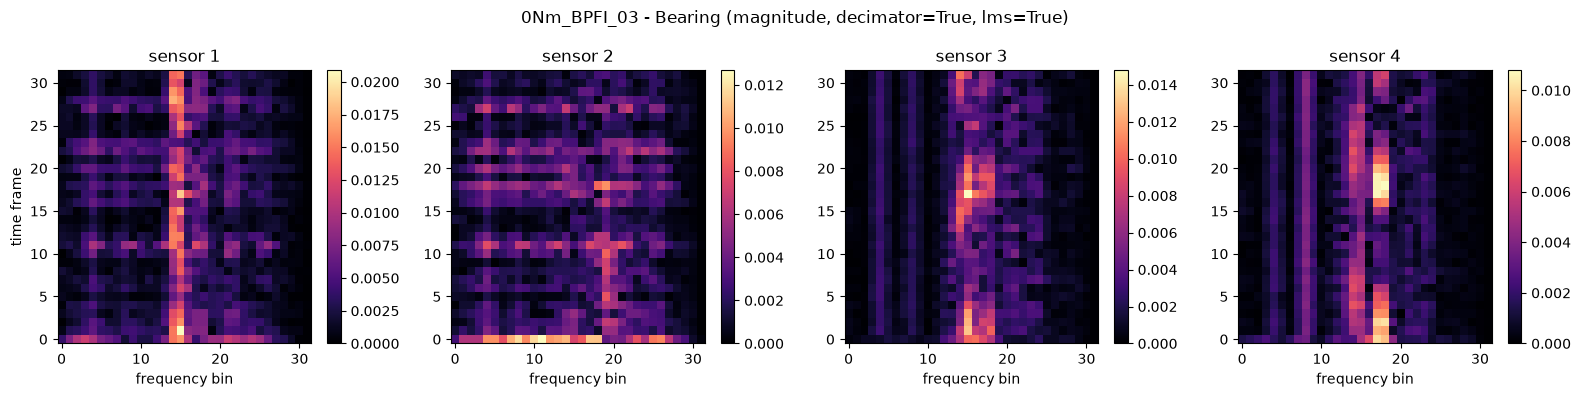

[CHECK] code range across the four sensors: [0, 685] of the +/-8388607 Q9.15 span


In [66]:
# Visual check: one image from each of the four sensors of a single case.
_case = next(case for case in CASES if case.label == 3)
_needed = FRONT_END.raw_samples_for_rows(SPEC_FRAMES)
_images = [images_from_rows(FRONT_END.rows(read_mem_file(path, max_samples=_needed)),
                            SPEC_FRAMES)[0]
           for path in _case.sensor_files]

_figure, _axes = plt.subplots(1, N_VIB, figsize=(16, 4))
for _index, (_axis, _image) in enumerate(zip(_axes, _images)):
    _handle = _axis.imshow(q915_to_float(_image), aspect="auto", origin="lower",
                           cmap="magma")
    _axis.set_title(f"sensor {_index + 1}")
    _axis.set_xlabel("frequency bin")
    _axis.set_ylabel("time frame" if _index == 0 else "")
    _figure.colorbar(_handle, ax=_axis)

_figure.suptitle(f"{_case.name} - {CLASS_NAMES[_case.label]} "
                 f"({FRONT_END.source}, decimator={FRONT_END.use_decimator}, "
                 f"lms={FRONT_END.use_lms})")
plt.tight_layout()
plt.show()

print(f"[CHECK] code range across the four sensors: "
      f"[{min(i.min() for i in _images)}, {max(i.max() for i in _images)}] "
      f"of the +/-{Q915_MAX} Q9.15 span")

### 9. Building the dataset

#### Why the old build was starved

The capture set is 4,500 s of signal in total, and it is shorter than it
looks: only one capture runs 300 s, twenty-six run 120 s and eighteen run
60 s. With the decimator on, one image spans

    SPEC_FRAMES x FFT_HOP x DECIM_RATE = 32 x 64 x 32 = 65,536 raw samples

which is **2.56 s**. That puts a hard ceiling of about 1,750 non-overlapping
images on the entire dataset, and the previous budget capped it further at
1,049. A four-class CNN trained on 1,049 images could not learn Normal at all.

#### Three levers

`ROW_HOP` is the cheap one and it is free. The RTL emits one continuous stream
of spectrogram rows; `cnn_top` happens to consume them 32 at a time, but
nothing stops the host from cutting that same stream into overlapping 32-row
images when building a *training* set. `ROW_HOP = 32` reproduces the fabric's
disjoint framing; `ROW_HOP = 8` gives four times as many images from the same
signal. Measured, magnitude spectrogram, decimator on, case-level split,
three seeds:

| ROW_HOP | images | accuracy | Normal | Unbalance | Misalign | Bearing |
| --- | --- | --- | --- | --- | --- | --- |
| 32 | 1,637 | 76.8 ±0.5 | 10.9 | 97.7 | 50.0 | 100 |
| 16 | 3,255 | 84.9 ±2.2 | 76.1 | 99.0 | 50.0 | 100 |
| 8 | 6,509 | 87.7 ±0.2 | 96.6 | 100 | 50.0 | 100 |
| 4 | 13,018 | 88.0 ±0.1 | 99.2 | 100 | 50.0 | 100 |

These are more views of the same signal, not more information - but the model
was starved of gradient steps, and Normal recall going from 11 % to 97 % is
what that starvation looked like.

`FFT_HOP` is the second lever and it is an RTL change: dropping it from 64 to
16 gives 75 % frame overlap and therefore four times as many *genuinely new*
rows. On its own it reaches 85.2 % with 98 % Normal recall at only 2,371
non-overlapping images; combined with `ROW_HOP = 8` it gives 9,489 images at
**89.1 % ±0.0**. It costs four times the FFT and CNN rate, which the timing
budget absorbs easily, and it changes `FRAMES_PER_ROUND` for the testbench.

`DECIM_RATE` is the third and it trades resolution for volume. Bypassing the
decimator makes images cheap - 2,048 raw samples each, so tens of thousands are
available - but at 400 Hz per bin instead of 12.5 Hz, which folds the whole
sub-200 Hz diagnostic band into bin 0. On its own that is fatal: 52.7 % ±1.0
with 0 % Normal recall. With the LMS in front of it, which at the shipped step
size only adapts on the undecimated stream, it recovers to 75.0 % ±0.6. Still
short of the 87.7 % the decimating build reaches, so the bypass costs about
13 points however it is configured. Section 7 has the full table.

#### Balancing

The case mix is skewed: three Normal captures against nine Misalign, fifteen
Unbalance and eighteen bearing. `IMAGES_PER_CLASS` is a budget spread across
each class's captures rather than a flat per-case count, so every class lands
near the same total. `MAX_ROWS_PER_CASE` remains the ceiling one capture may
supply, and the loss is class-weighted on top.

The result is cached as one `.npz` keyed by every setting that affects it, so
flipping a switch builds a second cache rather than overwriting the first.

In [67]:
# ============================================================================
# Dataset construction
# ============================================================================
IMAGES_PER_CLASS = 2400           # budget spread over each class's captures
MAX_ROWS_PER_CASE = 200_000       # ceiling one capture may supply
BALANCE_CLASSES = True


def rows_available(case: CaptureCase, front_end: SpectrogramFrontEnd) -> int:
    """Spectrogram rows a capture can yield, from its size on disk."""
    samples = case.sensor_files[0].stat().st_size // MEM_LINE_BYTES
    inner = samples // front_end.decimation
    if inner < FRAME_SIZE:
        return 0
    return (inner - FRAME_SIZE) // front_end.hop_size + 1


def rows_per_case(cases: list[CaptureCase], front_end: SpectrogramFrontEnd,
                  images_per_class: int = IMAGES_PER_CLASS,
                  row_hop: int = ROW_HOP, balance: bool = BALANCE_CLASSES,
                  cap: int = MAX_ROWS_PER_CASE) -> dict[int, int]:
    """How many rows to read from each case, keyed by its index in `cases`."""
    budget: dict[int, int] = {}
    for label in range(NUM_CLASSES):
        members = [index for index, case in enumerate(cases) if case.label == label]
        if not members:
            continue
        wanted_images = (max(1, round(images_per_class / len(members)))
                         if balance else images_per_class)
        wanted_rows = SPEC_FRAMES + (wanted_images - 1) * row_hop
        for index in members:
            budget[index] = min(wanted_rows, cap,
                                rows_available(cases[index], front_end))
    return budget


def build_dataset(cases: list[CaptureCase], front_end: SpectrogramFrontEnd,
                  budget: dict[int, int] | None = None, row_hop: int = ROW_HOP
                  ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Builds the image set.

    Returns (features, labels, case_ids): (N, frames, bins, sensors) int32,
    (N,) int64 and (N,) int64. `case_ids` indexes `cases` and exists so the
    train/validation split can keep whole captures on one side.
    """
    budget = budget if budget is not None else rows_per_case(cases, front_end)
    feature_blocks: list[np.ndarray] = []
    label_blocks: list[np.ndarray] = []
    case_blocks: list[np.ndarray] = []

    for index, case in enumerate(cases):
        wanted_rows = budget.get(index, 0)
        if wanted_rows < SPEC_FRAMES:
            print(f"[{index + 1:02d}/{len(cases)}] {case.name:<24s} -> too short")
            continue

        needed = front_end.raw_samples_for_rows(wanted_rows)
        channels = [front_end.rows(read_mem_file(path, max_samples=needed))
                    for path in case.sensor_files]

        # Every sensor of a case is the same length, but clip to the shortest
        # so a truncated file can never misalign the four channels.
        shortest = min(channel.shape[0] for channel in channels)
        images = [images_from_rows(channel[:shortest], row_hop)
                  for channel in channels]

        count = min(image.shape[0] for image in images)
        if count == 0:
            print(f"[{index + 1:02d}/{len(cases)}] {case.name:<24s} -> no complete image")
            continue

        stacked = np.stack([image[:count] for image in images], axis=-1)
        feature_blocks.append(stacked.astype(np.int32))
        label_blocks.append(np.full(count, case.label, dtype=np.int64))
        case_blocks.append(np.full(count, index, dtype=np.int64))

        print(f"[{index + 1:02d}/{len(cases)}] {case.name:<24s} -> "
              f"{shortest:6d} rows -> {count:5d} images ({CLASS_NAMES[case.label]})")

    if not feature_blocks:
        raise RuntimeError("No images were produced; check the row budget")

    return (np.concatenate(feature_blocks),
            np.concatenate(label_blocks),
            np.concatenate(case_blocks))


def dataset_cache_path(front_end: SpectrogramFrontEnd, budget: dict[int, int],
                       row_hop: int = ROW_HOP) -> Path:
    """One cache per distinct front end and budget."""
    tag = (f"dec{front_end.decimation}"
           f"_lms{int(front_end.use_lms)}{front_end.mu_shift if front_end.use_lms else ''}"
           f"_{front_end.source}"
           f"_hop{front_end.hop_size}"
           f"_rh{row_hop}"
           f"_r{sum(budget.values())}")
    return CACHE_DIR / f"spectrograms_{tag}.npz"


def load_or_build_dataset(cases: list[CaptureCase], front_end: SpectrogramFrontEnd,
                          budget: dict[int, int] | None = None,
                          row_hop: int = ROW_HOP, rebuild: bool = False
                          ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Builds the dataset, or reuses the cache built for these exact settings."""
    budget = budget if budget is not None else rows_per_case(cases, front_end,
                                                             row_hop=row_hop)
    path = dataset_cache_path(front_end, budget, row_hop)
    if path.is_file() and not rebuild:
        print(f"[DATASET] Reusing {path.name}")
        with np.load(path) as archive:
            return archive["features"], archive["labels"], archive["case_ids"]

    features, labels, case_ids = build_dataset(cases, front_end, budget, row_hop)
    np.savez_compressed(path, features=features, labels=labels, case_ids=case_ids)
    print(f"[DATASET] Cached {features.shape[0]} images to {path.name}")
    return features, labels, case_ids

In [68]:
BUDGET = rows_per_case(CASES, FRONT_END)
for _label, _name in enumerate(CLASS_NAMES):
    _members = [i for i, case in enumerate(CASES) if case.label == _label]
    if _members:
        _rows = sum(BUDGET[i] for i in _members)
        _imgs = sum(max(0, (BUDGET[i] - SPEC_FRAMES) // ROW_HOP + 1) for i in _members)
        print(f"[BUDGET] {_name:<10s} {len(_members):2d} cases, {_rows:7d} rows "
              f"-> ~{_imgs:5d} images at row_hop {ROW_HOP}")

FEATURES, LABELS, CASE_IDS = load_or_build_dataset(CASES, FRONT_END, BUDGET)

print(f"\n[DATASET] features {FEATURES.shape} {FEATURES.dtype} "
      f"({FEATURES.nbytes / 2**20:.0f} MiB)")
print(f"[DATASET] Q9.15 codes span [{FEATURES.min()}, {FEATURES.max()}] "
      f"-> [{q915_to_float(FEATURES.min()):.4f}, {q915_to_float(FEATURES.max()):.4f}]")

_counts = np.bincount(LABELS, minlength=NUM_CLASSES)
for _label, _name in enumerate(CLASS_NAMES):
    _share = 100.0 * _counts[_label] / LABELS.size
    print(f"  {_label} {_name:<10s} {_counts[_label]:6d} images  ({_share:5.1f} %)")

[BUDGET] Normal      3 cases,    6750 rows -> ~  833 images at row_hop 8
[BUDGET] Unbalance  15 cases,   19560 rows -> ~ 2400 images at row_hop 8
[BUDGET] Misalign    9 cases,   13500 rows -> ~ 1656 images at row_hop 8
[BUDGET] Bearing    18 cases,   13500 rows -> ~ 1620 images at row_hop 8
[DATASET] Reusing spectrograms_dec32_lms116_magnitude_hop64_rh8_r53310.npz

[DATASET] features (6509, 32, 32, 4) int32 (102 MiB)
[DATASET] Q9.15 codes span [0, 2635] -> [0.0000, 0.0804]
  0 Normal        833 images  ( 12.8 %)
  1 Unbalance    2400 images  ( 36.9 %)
  2 Misalign     1656 images  ( 25.4 %)
  3 Bearing      1620 images  ( 24.9 %)


### 9. Dataset wrapper and the float32 twin of `cnn_top`

The network is deliberately tiny because it has to fit the fabric: one 3x3
convolution to eight feature maps, ReLU, a 2x2 max pool, and a single dense
layer to four logits. Nothing else - no batch norm, no second convolution,
no dropout - because `cnn_top` has no hardware for any of it.

The only subtlety is the flatten, and it is the one described in section 3.
`self.pool` produces `(N, 8, 16, 16)`; the permute to `(N, 16, 16, 8)` before
flattening puts the features in `dense_layer_fsm`'s order, so
`dense.weight[class, feature]` exports straight to the ROM with no shuffling.

**Splitting by case, not by image.** Consecutive images inside one capture are
2.56 s windows of the same run under the same fault at the same severity, so
a random image-level split puts near-duplicates on both sides and reports an
accuracy that says nothing about a new machine. `SPLIT_BY_CASE` keeps whole
captures together. It costs several points of reported accuracy and is worth
every one of them; set it False to reproduce the optimistic number.

In [69]:
# ============================================================================
# PyTorch dataset and model
# ============================================================================
class SpectrogramDataset(Dataset):
    """Q9.15 spectrograms held in RAM as float32 tensors, (N, C, H, W)."""

    def __init__(self, features: np.ndarray, labels: np.ndarray):
        scaled = features.astype(np.float32) / np.float32(SCALE)
        self.inputs = torch.from_numpy(scaled).permute(0, 3, 1, 2).contiguous()
        self.targets = torch.from_numpy(labels.astype(np.int64))

    def __len__(self) -> int:
        return int(self.targets.numel())

    def __getitem__(self, index):
        return self.inputs[index], self.targets[index]


class CnnClassifier(nn.Module):
    """Float32 twin of cnn_top."""

    def __init__(self, in_channels: int = N_VIB, conv_channels: int = CONV_CHANNELS,
                 num_classes: int = NUM_CLASSES):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, conv_channels,
                              kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=POOL_SIZE, stride=POOL_SIZE)
        self.dense = nn.Linear(IN_FEATURES, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool(self.relu(self.conv(x)))
        # (N, C, H, W) -> (N, H, W, C): dense_layer_fsm walks pixels outermost
        # and the eight pooled channels innermost. See section 3.
        x = x.permute(0, 2, 3, 1).contiguous()
        return self.dense(x.flatten(1))


_preview = CnnClassifier()
_logits = _preview(torch.zeros(1, N_VIB, SPEC_FRAMES, SPEC_BINS))
print(_preview)
print(f"\n[MODEL] logits {tuple(_logits.shape)} (expected (1, {NUM_CLASSES}))")
print(f"[MODEL] conv  {tuple(_preview.conv.weight.shape)} + "
      f"{tuple(_preview.conv.bias.shape)}")
print(f"[MODEL] dense {tuple(_preview.dense.weight.shape)} + "
      f"{tuple(_preview.dense.bias.shape)}")
print(f"[MODEL] parameters: {sum(p.numel() for p in _preview.parameters())}")

CnnClassifier(
  (conv): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dense): Linear(in_features=2048, out_features=4, bias=True)
)

[MODEL] logits (1, 4) (expected (1, 4))
[MODEL] conv  (8, 4, 3, 3) + (8,)
[MODEL] dense (4, 2048) + (4,)
[MODEL] parameters: 8492


### 10. Training

Weighted cross-entropy against inverse class frequency, Adam, a step schedule
that halves the learning rate every fifteen epochs, and early stopping on
validation loss with the best weights restored at the end. The class weights
are load-bearing on top of the image budget: the capture set runs from three
Normal cases to eighteen bearing cases, and an unweighted loss can reach 40 %
by never predicting Normal at all.

**What to expect.** The number depends on the front end, and the spread is
wide - section 7 has the full table. As shipped (`DECIM_RATE = 1`, `USE_LMS =
1`, magnitude, `ROW_HOP = 8`) this lands near **75 %**. Switch the decimator
back in and it reaches **87.7 %**, which is the best this capture set supports.

The headline number understates the decimating build. Of eleven held-out
captures, **ten are classified 100 % correctly**; the single failure is
`0Nm_Misalign_01`, the mildest misalignment at zero load, read unanimously as
Normal. That is the physically hardest call in the set, and because only two
Misalign captures are held out, one failure pins that class at exactly 50 %.
It is one capture, not diffuse error.

Only three Normal captures exist in the whole set and they are three different
torque levels, so a case-level split always validates on an unseen operating
point. That is the honest measurement, and it is a statement about the capture
set rather than about the network.

In [70]:
# ============================================================================
# Training utilities
# ============================================================================
SPLIT_BY_CASE = True
VALIDATION_FRACTION = 0.25


class EarlyStopping:
    """Stops when validation loss stalls, keeping the best weights seen."""

    def __init__(self, patience: int = 10, delta: float = 0.0):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_loss = np.inf
        self.best_state = None
        self.should_stop = False

    def __call__(self, validation_loss: float, model: nn.Module) -> None:
        if validation_loss < self.best_loss - self.delta:
            self.best_loss = validation_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True


def split_by_case(labels: np.ndarray, case_ids: np.ndarray,
                  validation_fraction: float = VALIDATION_FRACTION,
                  seed: int = SEED) -> tuple[np.ndarray, np.ndarray]:
    """Holds out whole captures, keeping every class present on both sides."""
    generator = np.random.default_rng(seed)
    validation_cases: list[int] = []

    for label in range(NUM_CLASSES):
        members = np.unique(case_ids[labels == label])
        if members.size == 0:
            continue
        # At least one case held out, and at least one left to train on.
        take = int(round(validation_fraction * members.size))
        take = max(1, min(take, members.size - 1)) if members.size > 1 else 0
        if take:
            validation_cases.extend(generator.permutation(members)[:take].tolist())

    validation_mask = np.isin(case_ids, validation_cases)
    return np.flatnonzero(~validation_mask), np.flatnonzero(validation_mask)


def split_by_image(labels: np.ndarray, validation_fraction: float = VALIDATION_FRACTION,
                   seed: int = SEED) -> tuple[np.ndarray, np.ndarray]:
    """Plain shuffled split. Optimistic: neighbouring images share a capture."""
    generator = np.random.default_rng(seed)
    order = generator.permutation(labels.size)
    cut = int(round((1.0 - validation_fraction) * labels.size))
    return order[:cut], order[cut:]


def class_weights_for(labels: np.ndarray) -> torch.Tensor:
    """Inverse-frequency weights, normalised to a mean of one."""
    counts = np.bincount(labels, minlength=NUM_CLASSES).astype(np.float64)
    weights = np.where(counts > 0, labels.size / np.maximum(counts, 1), 0.0)
    weights = weights / weights[weights > 0].mean()
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)

In [71]:
# ============================================================================
# Training loop
# ============================================================================
def train_and_evaluate(features: np.ndarray, labels: np.ndarray, case_ids: np.ndarray,
                       epochs: int = 60, batch_size: int = 32,
                       learning_rate: float = 1e-3, patience: int = 10):
    """Trains one CnnClassifier and returns (history, confusion matrix, model)."""
    if SPLIT_BY_CASE:
        train_index, validation_index = split_by_case(labels, case_ids)
        split_kind = "case-level"
    else:
        train_index, validation_index = split_by_image(labels)
        split_kind = "image-level"

    dataset = SpectrogramDataset(features, labels)
    train_loader = DataLoader(Subset(dataset, train_index.tolist()),
                              batch_size=batch_size, shuffle=True)
    validation_loader = DataLoader(
        Subset(dataset, validation_index.tolist()),
        batch_size=batch_size, shuffle=False)

    print(f"[TRAIN] {split_kind} split: {train_index.size} train / "
          f"{validation_index.size} validation images")
    print(f"[TRAIN] validation classes: "
          f"{np.bincount(labels[validation_index], minlength=NUM_CLASSES).tolist()}")

    model = CnnClassifier().to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights_for(labels[train_index]))
    optimiser = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.StepLR(optimiser, step_size=15, gamma=0.5)
    stopper = EarlyStopping(patience=patience)

    history = {"train_loss": [], "train_accuracy": [],
               "validation_loss": [], "validation_accuracy": []}
    best_accuracy = 0.0
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()
        running_loss = correct = seen = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            optimiser.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimiser.step()

            running_loss += loss.item() * inputs.size(0)
            correct += (outputs.argmax(dim=1) == targets).sum().item()
            seen += inputs.size(0)

        history["train_loss"].append(running_loss / seen)
        history["train_accuracy"].append(correct / seen)

        model.eval()
        running_loss = correct = seen = 0.0
        with torch.no_grad():
            for inputs, targets in validation_loader:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                outputs = model(inputs)
                running_loss += criterion(outputs, targets).item() * inputs.size(0)
                correct += (outputs.argmax(dim=1) == targets).sum().item()
                seen += inputs.size(0)

        validation_loss = running_loss / seen
        validation_accuracy = correct / seen
        history["validation_loss"].append(validation_loss)
        history["validation_accuracy"].append(validation_accuracy)

        if validation_accuracy > best_accuracy:
            best_accuracy = validation_accuracy
            best_state = copy.deepcopy(model.state_dict())

        scheduler.step()
        print(f"epoch {epoch + 1:03d}/{epochs:03d} | "
              f"train {history['train_loss'][-1]:.4f} / "
              f"{history['train_accuracy'][-1] * 100:5.2f}% | "
              f"validation {validation_loss:.4f} / {validation_accuracy * 100:5.2f}%")

        stopper(validation_loss, model)
        if stopper.should_stop:
            print(f"[TRAIN] Early stop at epoch {epoch + 1}")
            break

    model.load_state_dict(best_state)
    print(f"[TRAIN] Best validation accuracy: {best_accuracy * 100:.2f}%")

    model.eval()
    predictions, truths = [], []
    with torch.no_grad():
        for inputs, targets in validation_loader:
            predictions.extend(model(inputs.to(DEVICE)).argmax(dim=1).cpu().numpy())
            truths.extend(targets.numpy())

    matrix = confusion_matrix(truths, predictions, labels=list(range(NUM_CLASSES)))
    return history, matrix, model

[TRAIN] case-level split: 4957 train / 1552 validation images
[TRAIN] validation classes: [184, 640, 368, 360]
epoch 001/060 | train 1.2956 / 48.03% | validation 1.1552 / 40.91%
epoch 002/060 | train 0.9169 / 70.77% | validation 0.9178 / 70.49%
epoch 003/060 | train 0.7071 / 73.47% | validation 0.8537 / 66.82%
epoch 004/060 | train 0.5978 / 76.15% | validation 0.7700 / 73.45%
epoch 005/060 | train 0.5259 / 80.92% | validation 0.7423 / 75.45%
epoch 006/060 | train 0.4705 / 83.07% | validation 0.6961 / 76.29%
epoch 007/060 | train 0.4202 / 85.64% | validation 0.6715 / 76.29%
epoch 008/060 | train 0.3792 / 87.45% | validation 0.6496 / 77.45%
epoch 009/060 | train 0.3431 / 89.07% | validation 0.6368 / 77.58%
epoch 010/060 | train 0.3130 / 90.54% | validation 0.6254 / 82.35%
epoch 011/060 | train 0.2886 / 91.14% | validation 0.7051 / 78.22%
epoch 012/060 | train 0.2672 / 91.85% | validation 0.5911 / 82.99%
epoch 013/060 | train 0.2480 / 92.78% | validation 0.6130 / 85.70%
epoch 014/060 | tr

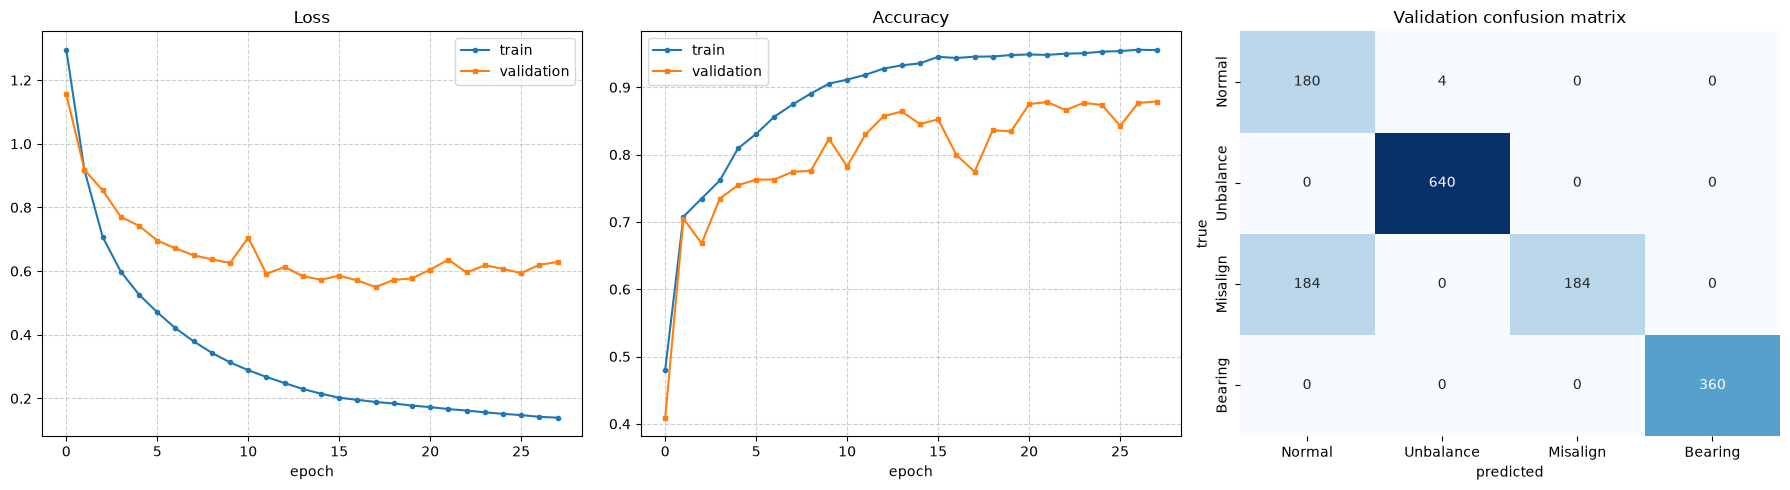

  Normal     recall  97.8%  (184 images)
  Unbalance  recall 100.0%  (640 images)
  Misalign   recall  50.0%  (368 images)
  Bearing    recall 100.0%  (360 images)


In [72]:
HISTORY, CONFUSION, MODEL = train_and_evaluate(FEATURES, LABELS, CASE_IDS, epochs=60)

_figure, _axes = plt.subplots(1, 3, figsize=(18, 5))

_axes[0].plot(HISTORY["train_loss"], label="train", marker="o", markersize=3)
_axes[0].plot(HISTORY["validation_loss"], label="validation", marker="s", markersize=3)
_axes[0].set_title("Loss")
_axes[0].set_xlabel("epoch")
_axes[0].legend()
_axes[0].grid(True, linestyle="--", alpha=0.6)

_axes[1].plot(HISTORY["train_accuracy"], label="train", marker="o", markersize=3)
_axes[1].plot(HISTORY["validation_accuracy"], label="validation", marker="s", markersize=3)
_axes[1].set_title("Accuracy")
_axes[1].set_xlabel("epoch")
_axes[1].legend()
_axes[1].grid(True, linestyle="--", alpha=0.6)

sns.heatmap(CONFUSION, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=_axes[2])
_axes[2].set_title("Validation confusion matrix")
_axes[2].set_xlabel("predicted")
_axes[2].set_ylabel("true")

plt.tight_layout()
plt.show()

for _label, _name in enumerate(CLASS_NAMES):
    _support = CONFUSION[_label].sum()
    _recall = CONFUSION[_label, _label] / _support if _support else float("nan")
    print(f"  {_name:<10s} recall {_recall * 100:5.1f}%  ({_support} images)")

### 11. Exporting the Q9.15 weights

Two artefacts leave this section:

* `cnn_model.pth` and `cnn_model_q915.npz` - the float32 state and the
  quantised integer archive, both kept beside the notebook and both
  gitignored.
* Four `.mem` ROM images, written to every directory in `EXPORT_DIRS`.

The ROM layouts follow the readers:

| file | words | order |
| --- | --- | --- |
| `conv2d_weights.mem` | 288 | `[out_channel][in_channel][row][col]` - `conv2d_fsm.sv:57-64` |
| `conv2d_biases.mem` | 8 | `[out_channel]` |
| `dense_weights.mem` | 8192 | `[class][feature]` - `dense_layer_fsm.sv:104` |
| `dense_biases.mem` | 4 | `[class]` |

Conv weights already match PyTorch's own memory order. Dense weights match
only because the model flattened in hardware order; see section 3.

The one number worth watching in the report below is how many coefficients
quantise to zero. Q9.15 resolves 3.05e-05, so a weight smaller than that
disappears entirely - that, not saturation, is the real risk at this scale.

In [73]:
# ============================================================================
# Q9.15 weight export
# ============================================================================
def export_q915_weights(model: CnnClassifier,
                        state_path: Path = MODEL_STATE_FILE,
                        archive_path: Path = MODEL_Q915_FILE) -> dict[str, np.ndarray]:
    """Saves the float32 state and returns the Q9.15 integer archive."""
    torch.save(model.state_dict(), state_path)
    print(f"[EXPORT] float32 state -> {state_path}")

    tensors = {
        "conv_weights": model.conv.weight,
        "conv_biases": model.conv.bias,
        "dense_weights": model.dense.weight,
        "dense_biases": model.dense.bias,
    }

    quantised: dict[str, np.ndarray] = {}
    for name, tensor in tensors.items():
        values = tensor.detach().cpu().numpy().astype(np.float64)
        codes = float_to_q915(values)
        quantised[name] = codes

        clipped = int(np.count_nonzero((codes == Q915_MIN) | (codes == Q915_MAX)))
        vanished = int(np.count_nonzero((codes == 0) & (values != 0.0)))
        print(f"[EXPORT] {name:<14s} {str(codes.shape):<16s} "
              f"float [{values.min():+.6f}, {values.max():+.6f}]  "
              f"codes [{codes.min()}, {codes.max()}]  "
              f"saturated {clipped}  flushed to zero {vanished}")

    np.savez(archive_path, **quantised)
    print(f"[EXPORT] Q9.15 archive -> {archive_path}")
    return quantised


def to_hex24(value) -> str:
    """Formats a signed integer as 24-bit two's complement hex."""
    return f"{int(value) & ((1 << TOTAL_BITS) - 1):0{HEX_DIGITS}X}"


def write_mem(path: Path, values) -> int:
    """Writes one hex word per line, the format $readmemh expects."""
    flat = np.asarray(values).reshape(-1)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="ascii", newline="\n") as handle:
        for value in flat:
            handle.write(to_hex24(value) + "\n")
    return flat.size


def export_rom_images(quantised: dict[str, np.ndarray],
                      directories: list[Path] = EXPORT_DIRS) -> None:
    """Writes the four ROM images cnn_top loads. See the table in section 11."""
    layout = {
        "conv2d_weights.mem": quantised["conv_weights"],
        "conv2d_biases.mem": quantised["conv_biases"],
        "dense_weights.mem": quantised["dense_weights"],
        "dense_biases.mem": quantised["dense_biases"],
    }
    for directory in directories:
        for filename, values in layout.items():
            written = write_mem(directory / filename, values)
            print(f"[EXPORT] {directory / filename} ({written} words)")

In [74]:
QUANTISED = export_q915_weights(MODEL)
export_rom_images(QUANTISED)

if not any(path == PROJECT_ROOT / "RTL" / "mem" / "cnn" for path in EXPORT_DIRS):
    print("\n[EXPORT] Reminder: RTL/mem/cnn/ is the tracked copy Quartus and "
          "top_system.sv read.\n"
          "         Copy the four .mem files across to promote this model.")

[EXPORT] float32 state -> /home/felipe/Documents/Projects/CI-Digital-PBL---Circuitos-Digitais-IV/Scripts/cnn/cnn_model.pth
[EXPORT] conv_weights   (8, 4, 3, 3)     float [-1.449416, +2.020689]  codes [-47494, 66214]  saturated 0  flushed to zero 0
[EXPORT] conv_biases    (8,)             float [-0.130823, +0.282400]  codes [-4287, 9254]  saturated 0  flushed to zero 0
[EXPORT] dense_weights  (4, 2048)        float [-1.869737, +1.692117]  codes [-61268, 55447]  saturated 0  flushed to zero 3
[EXPORT] dense_biases   (4,)             float [-0.155458, +0.107038]  codes [-5094, 3507]  saturated 0  flushed to zero 0
[EXPORT] Q9.15 archive -> /home/felipe/Documents/Projects/CI-Digital-PBL---Circuitos-Digitais-IV/Scripts/cnn/cnn_model_q915.npz
[EXPORT] /home/felipe/Documents/Projects/CI-Digital-PBL---Circuitos-Digitais-IV/Scripts/cnn/rtl/conv2d_weights.mem (288 words)
[EXPORT] /home/felipe/Documents/Projects/CI-Digital-PBL---Circuitos-Digitais-IV/Scripts/cnn/rtl/conv2d_biases.mem (8 words)
[E

### 12. Bit-true golden model

Pure NumPy, integers only, reproducing what the fabric computes rather than
what the float model computes. It exists so a mismatch against the RTL
testbench points at the RTL rather than at the arithmetic.

Every layer follows its module:

* **`Conv2dQ915`** - `conv2d_fsm.sv`. Eight parallel MACs walk the 36 window
  taps, the bias enters the accumulator multiplied by `1 << FRAC_BITS`
  (`conv2d_fsm.sv:172`), and the result is shifted and saturated once at the
  end.
* **`ReluQ915`** - `conv2d_fsm`'s output stage: sign bit set means zero.
* **`MaxPool2x2Q915`** - `maxpool_2x2.sv`, a comparator tree over 2x2.
* **`DenseQ915`** - `dense_layer_fsm.sv`, one MAC per class over all 2048
  features in hardware order.

The MAC deserves care, because the obvious model is wrong. `mac_q8_16.sv`
keeps a **48-bit accumulator of full-width products** and shifts only when the
result is read out. Rounding each product back to 24 bits first, which is what
a naive golden model does, throws away exactly the bits the hardware keeps and
drifts by tens of LSBs across 2048 accumulations. `wrap_signed(..., 48)`
reproduces the accumulator's own wraparound as well.

In [75]:
# ============================================================================
# Bit-true Q9.15 golden model
# ============================================================================
def mac_q915(accumulator):
    """Reads a mac_q8_16 accumulator out: wrap at 48 bits, shift, saturate."""
    return saturate(wrap_signed(accumulator, ACC_BITS) >> FRAC_BITS)


class Conv2dQ915:
    """conv2d_fsm.sv: 3x3 correlation over IN_CHANNELS, zero padding of 1."""

    def __init__(self, weights: np.ndarray, biases: np.ndarray,
                 kernel_size: int = 3, padding: int = 1):
        self.weights = np.asarray(weights, dtype=np.int64)
        self.biases = np.asarray(biases, dtype=np.int64)
        self.kernel_size = kernel_size
        self.padding = padding

    def forward(self, image: np.ndarray) -> np.ndarray:
        """(H, W, IC) -> (H, W, OC), all Q9.15."""
        height, width, _ = image.shape
        out_channels = self.weights.shape[0]

        padded = np.pad(image.astype(np.int64),
                        ((self.padding, self.padding),
                         (self.padding, self.padding), (0, 0)))
        # (H, W, IC, k, k), matching weights.reshape(OC, IC * k * k).
        windows = sliding_window_view(padded, (self.kernel_size, self.kernel_size),
                                      axis=(0, 1))
        patches = windows.reshape(height * width, -1)

        kernels = self.weights.reshape(out_channels, -1)
        accumulator = patches @ kernels.T
        accumulator = accumulator + (self.biases << FRAC_BITS)
        return mac_q915(accumulator).reshape(height, width, out_channels)


class ReluQ915:
    """Zeroes anything with the sign bit set."""

    def forward(self, image: np.ndarray) -> np.ndarray:
        return np.maximum(image, 0)


class MaxPool2x2Q915:
    """maxpool_2x2.sv: non-overlapping 2x2 maximum."""

    def __init__(self, pool_size: int = POOL_SIZE):
        self.pool_size = pool_size

    def forward(self, image: np.ndarray) -> np.ndarray:
        height, width, channels = image.shape
        size = self.pool_size
        reshaped = image.reshape(height // size, size, width // size, size, channels)
        return reshaped.max(axis=(1, 3))


class DenseQ915:
    """dense_layer_fsm.sv: one MAC per class over the flattened feature map."""

    def __init__(self, weights: np.ndarray, biases: np.ndarray):
        self.weights = np.asarray(weights, dtype=np.int64)
        self.biases = np.asarray(biases, dtype=np.int64)

    def forward(self, features: np.ndarray) -> np.ndarray:
        accumulator = self.weights @ features.astype(np.int64)
        accumulator = accumulator + (self.biases << FRAC_BITS)
        return mac_q915(accumulator)


class CnnGoldenModel:
    """The whole of cnn_top, in integers."""

    def __init__(self, quantised: dict[str, np.ndarray]):
        self.conv = Conv2dQ915(quantised["conv_weights"], quantised["conv_biases"])
        self.relu = ReluQ915()
        self.pool = MaxPool2x2Q915()
        self.dense = DenseQ915(quantised["dense_weights"], quantised["dense_biases"])

    @classmethod
    def from_archive(cls, path: Path = MODEL_Q915_FILE) -> "CnnGoldenModel":
        with np.load(path) as archive:
            return cls({name: archive[name] for name in archive.files})

    def forward(self, image: np.ndarray) -> np.ndarray:
        """(SPEC_FRAMES, SPEC_BINS, N_VIB) Q9.15 -> (NUM_CLASSES,) Q9.15 logits."""
        pooled = self.pool.forward(self.relu.forward(self.conv.forward(image)))
        # Row-major over (H, W, C) is exactly dense_layer_fsm's feature order.
        return self.dense.forward(pooled.reshape(-1))

### 13. Golden run and the testbench stimulus

The image below is drawn from a **held-out capture** so the comparison is not
made against something the network memorised. Three things are checked:

1. the float model and the golden model agree on the predicted class;
2. their logits agree to within the quantisation error;
3. the stimulus written for `tb_cnn_top.sv` is the same image the golden
   logits came from.

`cnn_tb_input.mem` is flattened `(32, 32, 4)` in C order, so the file reads
`pixel0_ch0..ch3, pixel1_ch0..ch3, ...` - which is how the testbench indexes
it at `tb_cnn_top.sv:63-66`. Run the testbench and the four logits it
prints should match the ones printed here.

In [76]:
# ============================================================================
# Golden model run and testbench export
# ============================================================================
def export_tb_input(image: np.ndarray, path: Path = TB_INPUT_FILE) -> None:
    """Writes one spectrogram as the testbench stimulus."""
    if image.shape != (SPEC_FRAMES, SPEC_BINS, N_VIB):
        raise ValueError(f"Expected {(SPEC_FRAMES, SPEC_BINS, N_VIB)}, got {image.shape}")
    written = write_mem(path, image.reshape(-1))
    print(f"[TB] {path} ({written} channel-pixels)")


# Same seed, same split, so this really is a held-out capture.
if SPLIT_BY_CASE:
    _, _validation_index = split_by_case(LABELS, CASE_IDS)
else:
    _, _validation_index = split_by_image(LABELS)

_sample = int(_validation_index[0])
_image = FEATURES[_sample].astype(np.int64)
_truth = int(LABELS[_sample])
_case_name = CASES[int(CASE_IDS[_sample])].name

GOLDEN_MODEL = CnnGoldenModel(QUANTISED)
_golden_logits = GOLDEN_MODEL.forward(_image)

MODEL.eval()
with torch.no_grad():
    _tensor = torch.from_numpy(
        q915_to_float(_image).astype(np.float32)).permute(2, 0, 1).unsqueeze(0)
    _float_logits = MODEL(_tensor.to(DEVICE)).cpu().numpy()[0]

_golden_class = int(np.argmax(_golden_logits))
_float_class = int(np.argmax(_float_logits))

print(f"[GOLDEN] sample {_sample} from {_case_name} (true class: {CLASS_NAMES[_truth]})")
print(f"{'class':<12s}{'float32':>12s}{'golden':>12s}{'golden code':>14s}")
for _index, _name in enumerate(CLASS_NAMES):
    print(f"{_name:<12s}{_float_logits[_index]:>12.5f}"
          f"{q915_to_float(_golden_logits[_index]):>12.5f}"
          f"{int(_golden_logits[_index]):>14d}")

print(f"\n[GOLDEN] float32 predicts {CLASS_NAMES[_float_class]}, "
      f"golden predicts {CLASS_NAMES[_golden_class]}")
print(f"[GOLDEN] argmax agrees: {_float_class == _golden_class}")
print(f"[GOLDEN] max logit error: "
      f"{np.abs(q915_to_float(_golden_logits) - _float_logits).max():.6f}")

export_tb_input(_image)

[GOLDEN] sample 180 from 0Nm_BPFI_30 (true class: Bearing)
class            float32      golden   golden code
Normal         -42.69811   -42.69373      -1398988
Unbalance       -3.21326    -3.21255       -105269
Misalign        -2.67392    -2.67352        -87606
Bearing         32.21624    32.21344       1055570

[GOLDEN] float32 predicts Bearing, golden predicts Bearing
[GOLDEN] argmax agrees: True
[GOLDEN] max logit error: 0.004383
[TB] /home/felipe/Documents/Projects/CI-Digital-PBL---Circuitos-Digitais-IV/Scripts/cnn/cnn_tb_input.mem (4096 channel-pixels)


### 14. Checklist before running the RTL

1. `USE_LMS`, `DECIM_RATE` and `FFT_HOP` in `system_types_pkg.sv` match the
   switches in cell 2. They are what `top_system.sv` passes to
   `dsp_preprocessing_subsystem`, and what `tb_top_system.sv` derives
   `FRAMES_PER_ROUND` from.
2. `FRAC_BITS` is 15 in `mac_q8_16.sv`, `cnn_top.sv`, `conv2d_fsm.sv`,
   `dense_layer_fsm.sv` and the four CNN testbenches. It is still 16 today.
3. The four `.mem` files have been copied from `Scripts/cnn/rtl/` to
   `RTL/mem/cnn/`, which is what `top_system.sv:40-43` and the `.qsf` read.
4. `cnn_tb_input.mem` sits beside this notebook, where
   `tb_cnn_top.sv:27` looks for it.
5. The logits printed in section 13 are the ones the testbench should print.